In [1]:
import os
from pathlib import Path
from typing import Any, Dict, List
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.typing import NDArray
from scipy.special import softmax #pyright: ignore
from skimage.measure import label, regionprops
from skimage.morphology import disk, binary_dilation
from skimage.segmentation import expand_labels

from model_ranking import load_h5

def get_mask(
    datapaths: Dict[str, Path],
    sid: str, 
    method: str, 
    file_ext: str =".h5", 
    seg_key: str = "segmentation"
):
    datapath = datapaths[method]
    mask_path = datapath / f"{sid}{file_ext}"
    return load_h5(mask_path, seg_key)


def create_pmask(seg_mask: NDArray[Any], r: int) -> NDArray[Any]:
    """converts a standard segmentation mask into one with a dilated area around 
    the center of the original mask"""
    mask = np.zeros_like(seg_mask)
    rps = regionprops(seg_mask) #pyright: ignore
    
    #get center of each cell and set the value to one
    centroids = np.array(
        list(map(lambda x : np.array(x.centroid).astype(int), rps)) #pyright: ignore
    )
    mask[centroids[:,0], centroids[:,1]] = 1
    
    #dilate around the center of the cell with the radius size and binarize the mask
    #mask = binary_dilation(mask, disk(r))
    mask = expand_labels(label(mask), distance=r) #pyright: ignore
    mask = (mask > 0).astype('int') #pyright: ignore
    
    return mask #pyright: ignore


def filter_pmask(mask: NDArray[Any], avg_labs: NDArray[Any]) -> NDArray[Any]:
    """filter probability mask for a single method (mask) using the thresholded, averaged, proability mask
    such that the new probability mask contains cell regions that only overlap with one cell region in the
    pseudo-ground-truth"""
    #copy 
    filtered = mask.copy()
    mask_lab = label(mask) #pyright: ignore
    rps = regionprops(mask_lab) #pyright: ignore
    
    for rp in rps: #for each cell region # pyright: ignore
        #get cell center coordinates from single-method mask
        coords = rp.coords  #pyright: ignore
        #use those coords to get values of averaged mask 
        vals = avg_labs[coords[:,0], coords[:,1]]
        uniq, counts = np.unique(vals, return_counts=True)
        
        #ignore background
        if uniq[0] == 0:
            uniq = uniq[1:]
            counts = counts[1:]
            
        n_unique = len(uniq)
        
        #if more than 1 value, zero out pixels in mask that do not equal the most common value
        if n_unique > 1:
            amax = np.argmax(counts)
            top_val = uniq[amax]
            idxs = np.where(vals != top_val)
            to_zero = coords[idxs,:][0] #pyright: ignore
            filtered[to_zero[:,0], to_zero[:,1]] = False
            
    return filtered


def f1_score(gt, m):
    """returns precision and recall for a pair of masks"""
    rps = regionprops(m)
    coords = list(map(lambda x : x.coords, rps))
    correct = 0
    
    for c in coords:
        correct += (gt[c[:,0], c[:,1]]).max()
    precision = correct / len(rps)
    
    gt_labs = label(gt)
    gt_rps = regionprops(gt_labs)
    coords = list(map(lambda x : x.coords, gt_rps))
    correct = 0
    
    for c in coords:
        correct += (m[c[:,0], c[:,1]]).max() > 0
    recall = correct / len(gt_rps)
    
    assert precision <= 1
    assert precision >= 0
    assert recall <= 1
    assert recall >= 0
    
    f1 = lambda p,r: 2 * (p * r) / (p + r)

    return f1(precision, recall)


def get_pseudo_ground_truths(
    pmasks: Dict[str, Dict[str, NDArray[Any]]], 
    sample_ids: List[str], 
    methods: List[str], 
    weights: NDArray[Any], 
    agree_ratio: float, 
    filtered: bool=False
):
    pseudo_gts: Dict[str, Dict[str, NDArray[Any]]] = {}
    for s,sid in enumerate(sample_ids):
        pseudo_gts[sid] = {}
        for method_out in methods:
            if filtered:
                pmasks_ = pmasks[method_out][sid] #filtered with resepect to method-left-out
            else:
                pmasks_ = pmasks[sid]
            methods_in = [m for m in methods if m != method_out]
            gt = sum([pmasks_[method]*weights[s][m] for m,method in enumerate(methods_in)])
            pseudo_gts[sid][method_out] = (gt >= agree_ratio).astype('int')   # pyright: ignore
    return pseudo_gts



def get_weights(datapaths: Dict[str, Path], sample_ids: List[str], methods: List[str], radius: int, agree_ratio: float): 
    # get probability masks
    pmasks: Dict[str, Dict[str, NDArray[Any]]] = {}
    for sid in sample_ids:
        pmasks[sid] = {}
        for method in methods:
            method_mask = get_mask(datapaths, sid, method)
            pmasks[sid][method] = create_pmask(method_mask, radius)
               
    #get pseudo-ground-truths for each method-left-out
    weights = np.ones((len(sample_ids), len(methods) - 1)) * (1/ (len(methods) - 1))
    pseudo_gts = get_pseudo_ground_truths(pmasks, sample_ids, methods, weights, agree_ratio)
    
    #filter probability masks
    f_pmasks = {}
    for method_out in methods:
        f_pmasks[method_out] = {}
        for sid in sample_ids:
            f_pmasks_ = {}
            for method_in in methods:
                if method_in == method_out: continue 
                f_pmasks_[method_in] = filter_pmask(pmasks[sid][method_in], label(pseudo_gts[sid][method_out])) #pyright: ignore
            f_pmasks[method_out][sid] = f_pmasks_
            
    #regenerate pseudo-ground-truths
    f_pseudo_gts =  get_pseudo_ground_truths(f_pmasks, sample_ids, methods, weights, agree_ratio, filtered=True)
    
    #generate F1 table (N X N), N=# of methods
    f1_table = np.zeros((len(sample_ids), len(methods), len(methods)))
    for s,sid in enumerate(sample_ids):
        for i,method_in in enumerate(methods):
            for j,method_out in enumerate(methods):
                if method_out == method_in: 
                    f1_table[s][i][j] = -999
                    continue
                method_mask = label(f_pmasks[method_out][sid][method_in])
                f1_table[s][i][j] = f1_score(f_pseudo_gts[sid][method_out], method_mask)  
                
    weights  = np.zeros((len(sample_ids),len(methods))) 
    for s,sid in enumerate(sample_ids):
        f1_t = f1_table[s]
        f1_t[f1_t == -999] = np.nan
        mF1 = np.nanmean(f1_t, axis=1)
        mean_mF1 = np.mean(mF1)
        z = 100 * (mF1 - mean_mF1) / mean_mF1
        weights[s] = softmax(z)
       
        
    return weights

INFO: P [MainThread] 2026-02-28 13:34:56,821 plantseg - Logger configured at initialisation. PlantSeg logger name: plantseg


/g/kreshuk/talks/pytorch-3dunet/pytorch3dunet/unet3d/utils.py:17: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/g/kreshuk/talks/miniforge3/envs/model-rank-local2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [20]:
def get_pseudo_ground_truths2(pmasks, sample_ids, methods, weights, agree_ratio):
    pseudo_gts = {}

    for s,sid in enumerate(sample_ids):
        gt = sum([pmasks[sid][method] * weights[s][m] for m,method in enumerate(methods)])
        pseudo_gts[sid] = (gt >= agree_ratio).astype('int')
    
    return pseudo_gts


def get_f1_scores(datapath, sample_ids, methods, weights, agree_ratio, radius):
    #get probability masks
    pmasks = {}
    for sid in sample_ids:
        pmasks[sid] = {}
        for method in methods:
            method_mask = get_mask(datapath, sid, method)
            pmasks[sid][method] = create_pmask(method_mask, radius)
            
    #get pseudo-ground-truths
    pseudo_gts = get_pseudo_ground_truths2(pmasks, sample_ids, methods, weights, agree_ratio)
    
    #filter probability masks
    f_pmasks = {}
    for sid in sample_ids:
        f_pmasks[sid] = {}
        for method in methods:
            f_pmasks[sid][method] = filter_pmask(pmasks[sid][method], label(pseudo_gts[sid]))
    
    #re-generate pseudo-ground-truths
    f_pseudo_gts = get_pseudo_ground_truths2(f_pmasks, sample_ids, methods, weights, agree_ratio)
    
    #calculate average F1-score per method across samples
    f1_per_method = []
    for method in methods:
        mean_method_f1s = np.mean([f1_score(f_pseudo_gts[sid], label(f_pmasks[sid][method])) for sid in sample_ids])
        f1_per_method.append(mean_method_f1s)
        
    return f1_per_method

In [2]:
from model_ranking import MODEL_ABBREVIATIONS_TO_DATASET
from pathlib import Path
from typing import Optional

def get_output_dir_paths(
    target: str,
    model_name: str,
    run_id: str,
    approach: str = "consistency",
    base_path: str = "/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells",
    output_dir_name: str = "predictions",
    specfic_perturbation: Optional[str] = None
):
    source = MODEL_ABBREVIATIONS_TO_DATASET[model_name.split("_")[0]]

    initial_path = Path(base_path) / f"{source}_to_{target}_gap/{approach}/{run_id}/{model_name}"

    if specfic_perturbation is not None:
        output_paths = list(initial_path.rglob(f"**/{specfic_perturbation}/{output_dir_name}"))

    else:
        output_paths = list(initial_path.rglob(f"**/{output_dir_name}"))
    
    return output_paths

In [168]:
#methods = ["Mesmer", "Stardist", "Cellpose", "UnMicst"]
methods = ["BC_IN_model2", "HN_IN_model2", "Hst_IN_model3", "895_IN_model2", "1410_IN_model1"]
base_path = "/g/kreshuk/talks/consistency_results/Instance_segmentation/nuclei"

agree_ratio = 0.3
radius = 30

In [169]:
model_pred_paths: Dict[str, Path] = {}
for model in methods:
    paths = get_output_dir_paths("Hoechst", model, "P1", base_path=base_path, specfic_perturbation="none")
    assert len(paths) == 1, f"Expected exactly one path for model {model}, found {len(paths)}"
    model_pred_paths[model] = paths[0]

In [170]:
filenames = sorted([Path(f).stem for f in os.listdir(model_pred_paths[methods[0]]) if f.endswith(".h5")])

In [180]:
sample_ids = filenames[0:2]

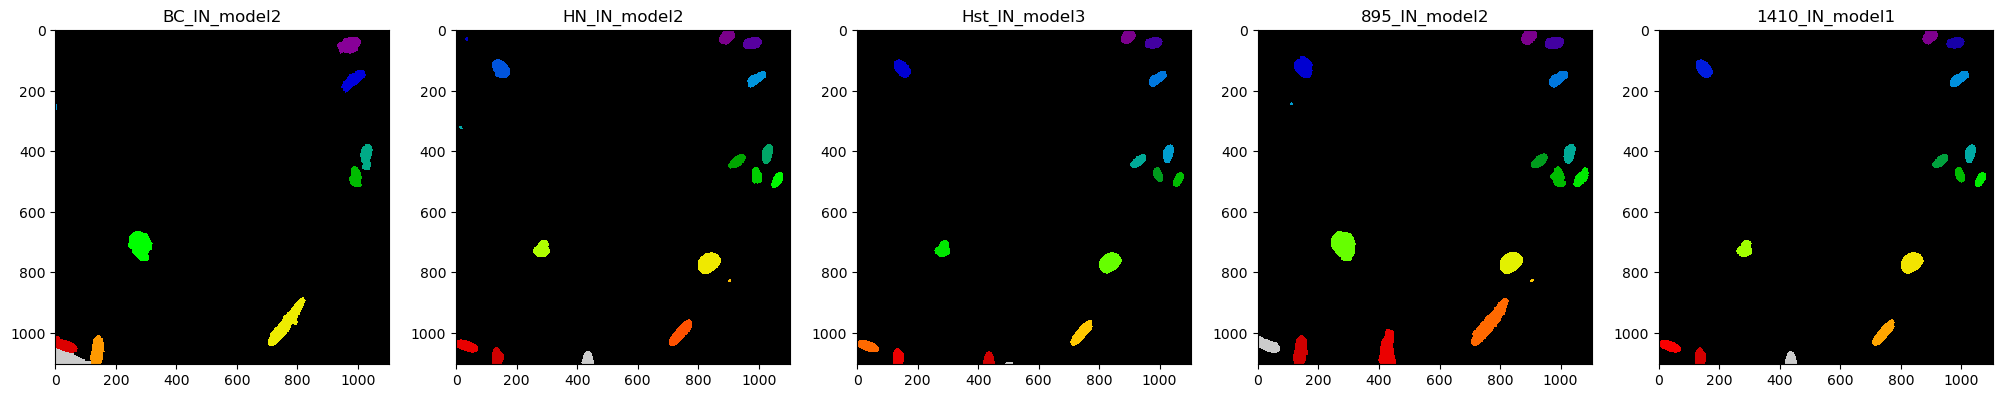

In [181]:
fig, ax  = plt.subplots(1,len(methods), figsize=(25,16))
for ax, model in zip(ax, methods):
    mask = get_mask(model_pred_paths, sample_ids[0], model)
    _ = ax.imshow(mask, interpolation='nearest', cmap="nipy_spectral")
    # _ = ax.axis('off')
    _ = ax.set_title(f'{model}')

In [182]:
equal_weights = np.ones((len(sample_ids),len(methods))) * (1 / len(methods))
unequal_weights = get_weights(model_pred_paths, sample_ids, methods, radius, agree_ratio=agree_ratio)

In [183]:
unequal_weights.shape

(2, 5)

In [185]:
print(pd.DataFrame(equal_weights.round(2), index=[0,1], columns=methods))
print(pd.DataFrame(unequal_weights.round(2), index=[0,1], columns=methods))

   BC_IN_model2  HN_IN_model2  Hst_IN_model3  895_IN_model2  1410_IN_model1
0           0.2           0.2            0.2            0.2             0.2
1           0.2           0.2            0.2            0.2             0.2
   BC_IN_model2  HN_IN_model2  Hst_IN_model3  895_IN_model2  1410_IN_model1
0          0.00          0.00           0.00           0.07            0.93
1          0.09          0.09           0.25           0.56            0.02


In [188]:
equal_weight_f1_scores = get_f1_scores(model_pred_paths, sample_ids, methods, equal_weights, agree_ratio, radius)
unequal_weight_f1_scores = get_f1_scores(model_pred_paths, sample_ids, methods, unequal_weights, agree_ratio, radius)

In [ ]:
def save_SEG_results(
    equal_weights, 
    unequal_weights, 
    equal_weight_f1_scores, 
    unequal_weight_f1_scores, 
    methods
):
    results = {
        "Method": methods,
        "Equal Weights": equal_weights,
        "Unequal Weights": unequal_weights,
        "F1 Score (Equal Weights)": equal_weight_f1_scores,
        "F1 Score (Unequal Weights)": unequal_weight_f1_scores
    }
    df = pd.DataFrame(results)
    df.to_csv("SEG_results.csv", index=False)

In [189]:
equal_weight_f1_scores

[0.825136612021858,
 0.9606854838709677,
 0.9475478625753999,
 0.9838709677419355,
 0.9660919540229884]

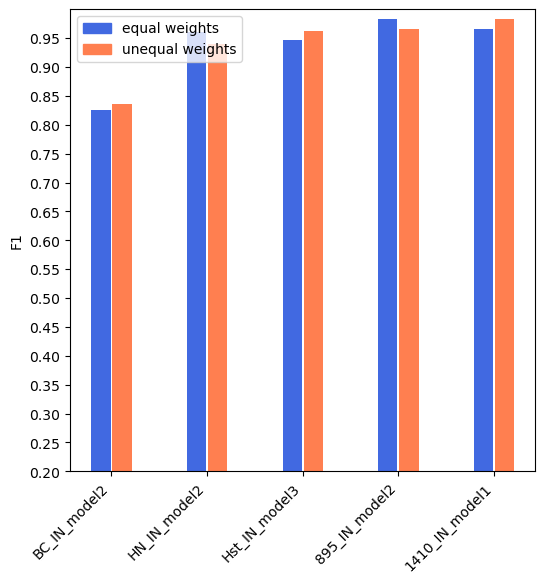

In [190]:
fig, ax = plt.subplots(1, figsize=(6,6))

ax.set(ylim=[0.90,1])

ax.bar(np.arange(5)-0.11, equal_weight_f1_scores, color='royalblue', width=0.2)
ax.bar(np.arange(5)+0.11, unequal_weight_f1_scores, color='coral', width=0.2)

plt.setp(ax, xticks=np.arange(5), xticklabels=methods)

labels = ['equal weights', 'unequal weights']
handles = [plt.Rectangle((0,0),1,1, color=c) for c in ['royalblue','coral']]

plt.yticks(np.arange(0.2, 1, 0.05))
plt.legend(handles, labels)
plt.xticks(rotation=45, ha='right')
plt.ylabel('F1')
plt.show()